# Notebook to generate Cartograms

## 0. Imports

In [1]:
import os
import sys
import numpy as np

project_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_dir)

from src.cartograms import *
from src.utils.common import *


In [2]:
region, level, year = get_region("usa") # world, india, usa, taiwan

## 1. DEMERS

Matched name column: 'Entity', value column: 'electoral_college'
Number of unmatched regions for year 2016: 0
Contiguous mode 'square': 0 shared-vertex penalty terms added.
Status : optimal
Obj val: 122.648


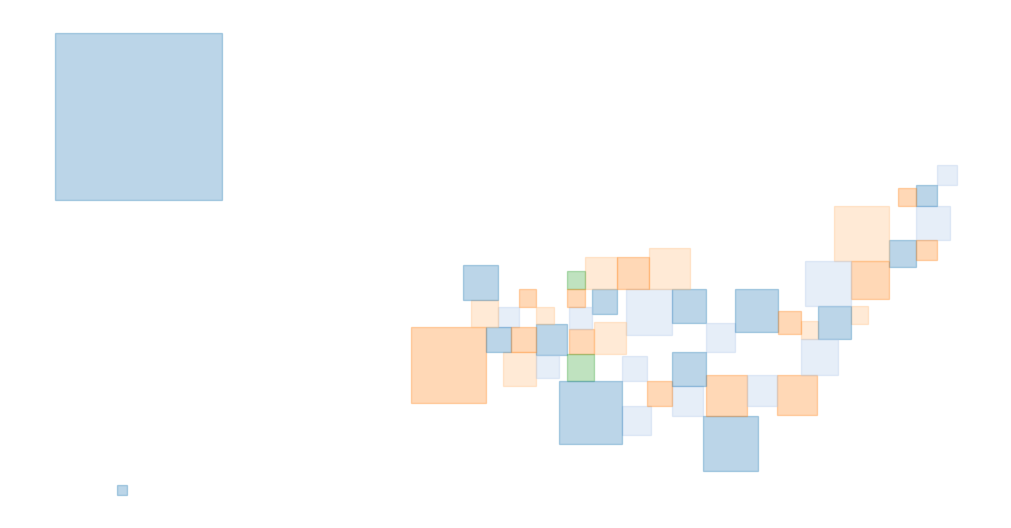

In [3]:
data = demers_cartogram(region, level, year)
plot_polys_data(data,  title=f"DEMERS {region}", centroids=False, legend=False, target_centers=None, svg=True)


In [4]:
# for state in data.keys():
#     print(abs(data[state]['new_area'] - data[state]['target_area'])/max(data[state]['new_area'], data[state]['target_area']))

## 2. Dorling

In [5]:
data = dorling_cartogram(region, level, year)
plot_polys_data(data,  title=f"DORLING {region}", centroids=False, legend=False, target_centers=None, svg=True)

Matched name column: 'Entity', value column: 'electoral_college'
Number of unmatched regions for year 2016: 0
Contiguous mode 'circle': 0 shared-vertex penalty terms added.


KeyboardInterrupt: 

In [ ]:
# for state in data.keys():
#     print(abs(data[state]['new_area'] - data[state]['target_area'])/max(data[state]['new_area'], data[state]['target_area']))

## 3. Non-Contiguous

Matched name column: 'Entity', value column: 'electoral_college'
Number of unmatched regions for year 2016: 0
  noncontiguous_cartogram: auto area_scale = 0.0042 (worst-case region growth capped at 1.0x its original area)
Contiguous mode 'original': 0 shared-vertex penalty terms added.
Status : optimal
Obj val: 11.4092


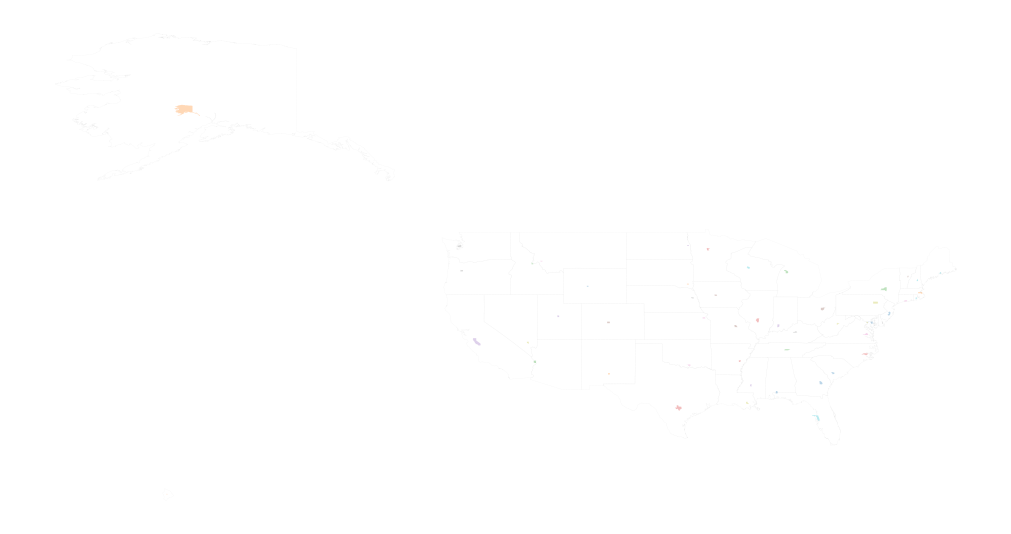

In [ ]:
data = noncontiguous_cartogram(region, level, year)
plot_polys_data(data,  title=f"NON-CONTIGUOUS {region}", plot_original_outlines=True, centroids=False, legend=False, target_centers=None, svg=True)

In [ ]:
# for state in data.keys():
#     print(abs(data[state]['new_area'] - data[state]['target_area'])/max(data[state]['new_area'], data[state]['target_area']))

## 4. Contiguous

Matched name column: 'Entity', value column: 'electoral_college'
Number of unmatched regions for year 2016: 0
Contiguous mode 'contiguous2': 2055 shared-vertex penalty terms added.


/home/kuenem/Documents/development/lectures/Master Thesis/Cartogram Framework/src/core/CartogramFramework_data.py:931: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  prob = cp.Problem(objective, constraints)
/home/kuenem/Documents/development/lectures/Master Thesis/Cartogram Framework/src/core/CartogramFramework_data.py:932: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  prob.solve(solver=cp.CLARABEL, verbose=False)


Status : optimal
Obj val: 25837.6
Post-processing: equalizing region areas on the raster grid (max_passes=30, tolerance=0.02)


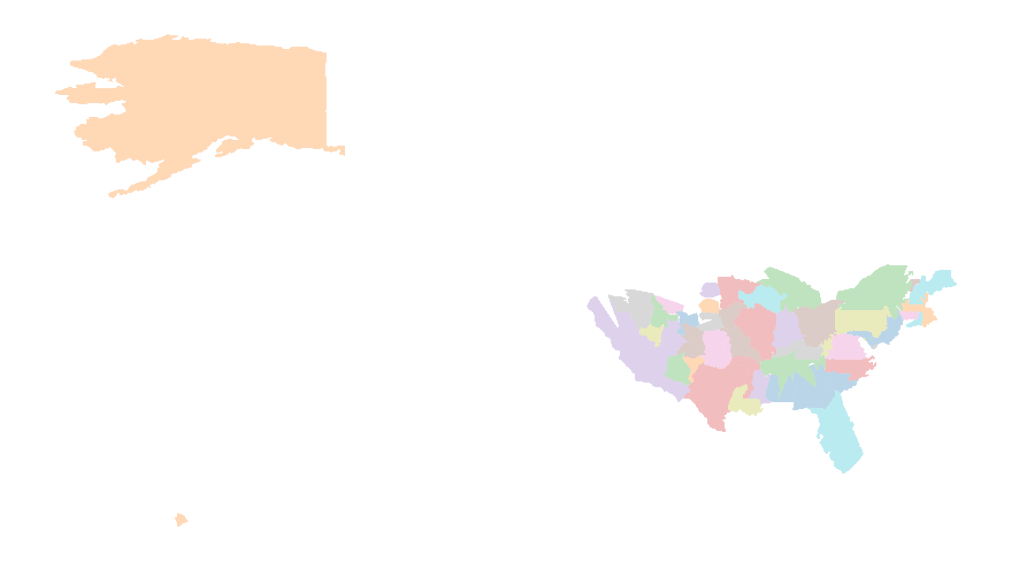

In [ ]:
data = contiguous_cartogram(region, level, year)
plot_polys_data(data,  title=f"CONTIGUOUS {region}", centroids=False, legend=False, target_centers=None, svg=True)

In [ ]:
def check_t_bounds(data, t_min=0.01, t_max=50.5):
    print(f"{'state':<20} {'orig_area':>14} {'target_area':>14} {'s=sqrt(ratio)':>14}  status")
    print("-" * 80)
    n_clipped = 0
    for name, record in data.items():
        if name == "__meta__":
            continue
        A0 = record.get("area", record.get("original_area"))
        ta = record.get("target_area")
        if A0 is None or ta is None or A0 <= 0:
            continue
        s = float(np.sqrt(ta / A0))
        status = ""
        if s > t_max:
            status = f"CLIPPED (needs s={s:.2f} > t_max={t_max})"
            n_clipped += 1
        elif s < t_min:
            status = f"CLIPPED (needs s={s:.4f} < t_min={t_min})"
            n_clipped += 1
        print(f"{name:<20} {A0:>14.2f} {ta:>14.2f} {s:>14.3f}  {status}")
    print("-" * 80)
    print(f"{n_clipped} / {len([k for k in data if k != '__meta__'])} states are asking for an s outside [t_min, t_max].")
    print("Those states CANNOT hit their target area at any objective weighting")
    print("-- only raising t_max / lowering t_min (or capping their target_area)")
    print("can fix them.")
check_t_bounds(data, t_min=0.01, t_max=98.5)

state                     orig_area    target_area  s=sqrt(ratio)  status
--------------------------------------------------------------------------------
Alabama                       12.86          12.42          0.982  
Alaska                       267.09         368.46          1.175  
Arizona                       28.93          15.17          0.724  
Arkansas                      13.58           8.28          0.781  
California                    41.54          75.87          1.351  
Colorado                      28.05          12.42          0.665  
Connecticut                    1.39           9.66          2.634  
Delaware                       0.55           4.14          2.741  
DistrictofColumbia             0.02           4.14         15.501  
Florida                       13.50          40.01          1.722  
Georgia                       14.59          22.07          1.230  
Hawaii                         0.90           1.24          1.175  
Idaho                        

In [ ]:
na = []
qa = []
for state in data.keys():
    na.append(abs(data[state]['new_area'] - data[state]['target_area'])/max(data[state]['new_area'], data[state]['target_area']))
    qa.append(abs(data[state]['qp_area'] - data[state]['target_area'])/max(data[state]['qp_area'], data[state]['target_area']))
    print(abs(data[state]['new_area'] - data[state]['target_area'])/max(data[state]['new_area'], data[state]['target_area']))
    print("Before Postprocessing:")
    print(abs(data[state]['qp_area'] - data[state]['target_area'])/max(data[state]['qp_area'], data[state]['target_area']))
print("Average new area error:", sum(na)/len(na))
print("Average qp area error:", sum(qa)/len(qa))

0.4305317510714892
Before Postprocessing:
0.3770168237090122
0.15383853593551847
Before Postprocessing:
0.1615671294413224
0.5698727496170949
Before Postprocessing:
0.5116706534732477
0.5958713249934537
Before Postprocessing:
0.05974904446953777
0.46144590408790803
Before Postprocessing:
0.4060554746678278
0.3905252000897607
Before Postprocessing:
0.2162802970235224
0.8239890358108991
Before Postprocessing:
0.722032118468143
0.941865480624454
Before Postprocessing:
0.515487930756431
0.983122236310297
Before Postprocessing:
0.933596157595767
0.3522430694345921
Before Postprocessing:
0.3148912713505981
0.4152558121764678
Before Postprocessing:
0.2933636305238903
0.031524601941182534
Before Postprocessing:
0.0026719706338991563
0.11813684721741327
Before Postprocessing:
0.04606942166083203
0.3623018285983984
Before Postprocessing:
0.28440345634602016
0.36017932195927943
Before Postprocessing:
0.3595614780499673
0.41959245978910775
Before Postprocessing:
0.0811923471115905
0.40646531024954

In [ ]:
print(type(data))
print(type(data["Alabama"]))
print(data["Alabama"].keys())
print(data["Alabama"]["new_area"])
print(data["Alabama"]["target_area"])

<class 'dict'>
<class 'dict'>
dict_keys(['area', 'polygon', 'target_positions', 'centroid', 'target_area', 'original_area', 'original_polygon', 'new_polygon', 'new_area', 'qp_area', 'new_centroid', 'overlap_area_lost', 'status', 'objective_value', 'constraints', 'objective'])
7.070430644787848
12.415846990751977
